In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm   
import pandas_ta as ta
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn import linear_model
sns.set_theme(style="whitegrid")
import re
pd.set_option('display.max_columns', None)

from sklearn.model_selection import train_test_split
import joblib


In [12]:
df = pd.read_csv("btc_usdc_30m_1year.csv")

In [13]:
df['Open time'] = pd.to_datetime(df['Open time'])
df = df.set_index('Open time')

In [14]:
df.head()

,Open,High,Low,Close,Volume
Open time,,,,,
2026-03-21 14:30:00,70918.04,71003.72,70584.98,70619.84,63.08624
2026-03-21 15:00:00,70617.94,70663.37,70450.00,70663.37,36.00151
2026-03-21 15:30:00,70663.37,70753.18,70594.35,70620.72,24.57761
2026-03-21 16:00:00,70620.72,70647.15,70321.80,70417.05,58.79691
2026-03-21 16:30:00,70411.47,70474.25,70242.34,70295.00,43.59162


In [15]:
df.sort_index(inplace=True)

df['sma_20'] = df.ta.sma(length=20)
df['sma_50'] = df.ta.sma(length=50)

df['rsi_14'] = df.ta.rsi(length=14)
df.ta.macd(append=True)

df['close_log_return'] = np.log(df['Close']/df['Close'].shift())
df['close_log_return_lag_1'] = df['close_log_return'].shift()
df['close_log_return_lag_2'] = df['close_log_return'].shift(2)
df['close_log_return_lag_3'] = df['close_log_return'].shift(3)

df = df.dropna()

In [16]:
df_X = df[['rsi_14', 'MACDh_12_26_9', 'MACD_12_26_9', 'close_log_return_lag_1', 
'close_log_return_lag_2', 'close_log_return_lag_3']]

In [17]:
results = joblib.load('model.joblib')

In [20]:
df['pred'] = results.predict(df_X)

In [22]:
df = df[df.index >= '2026-04-18 15:00:00']

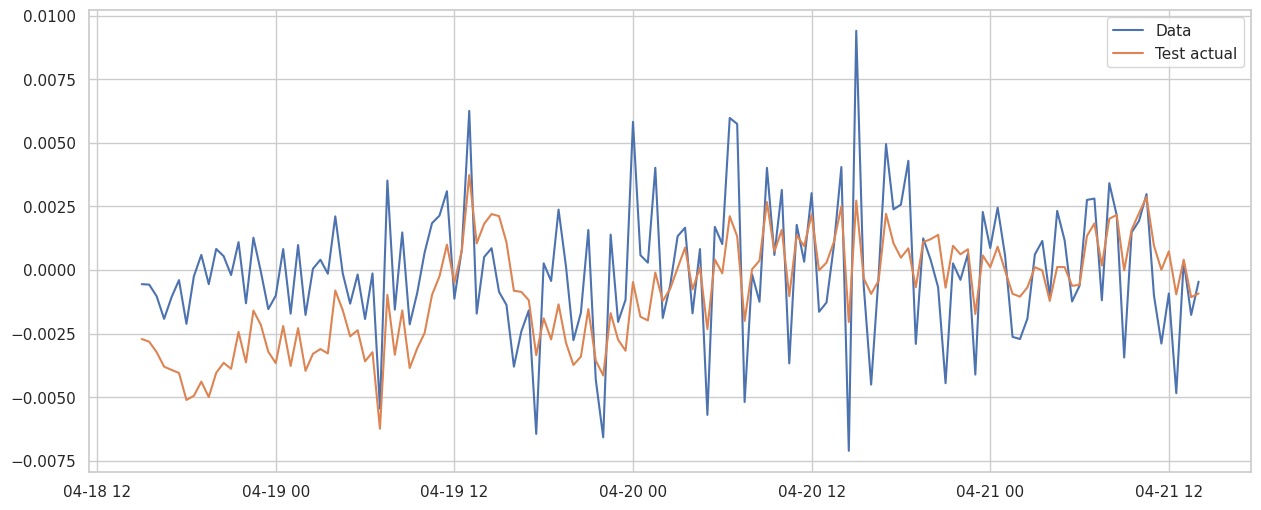

In [25]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['close_log_return'], label="Data")
plt.plot(df.index, df['pred'], label="Test actual")
plt.legend()

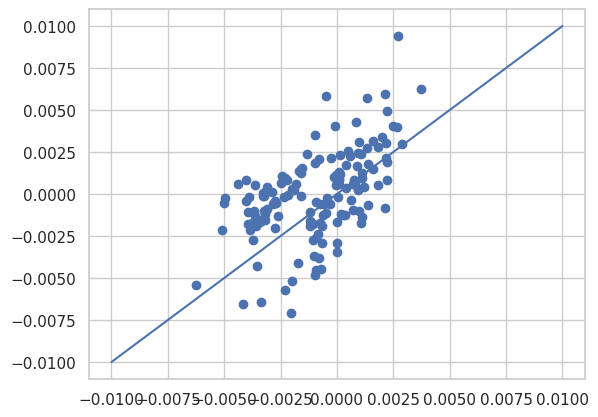

In [27]:
plt.scatter(df['pred'], df['close_log_return'], label="Test actual")
plt.plot([-0.01,0.01], [-0.01,0.01]);

In [28]:
df['won'] = np.sign(df['pred']) == np.sign(df['close_log_return'])
df['signal'] = np.sign(df['pred'])
df['trade_log_return_predict'] = df['signal']*df['close_log_return']
df['equity_curve_predict'] = df['trade_log_return_predict'].cumsum()

In [29]:
maker_fee = 0.000144
taker_fee = 0.000432

roundtrip_fee_log = np.log(1 - 2 * taker_fee)

df['fees'] = roundtrip_fee_log
df['trade_log_return_predict_fees'] = df['trade_log_return_predict'] + df['fees']
df['equity_curve_predict_fees'] = df['trade_log_return_predict_fees'].cumsum()

In [39]:

capital = 1000
ratio = 0.01 # you could experiment with different ratios like kelly criterion
trade_value = ratio * capital
df['entry_trace'] = trade_value

df['exit_trade_value'] = df['entry_trace']*np.exp(df['trade_log_return_predict'])
df['trade_qty'] = 0.0002#df['entry_trace'] / df['Open'] 
df['signed_trade_qty'] = df['trade_qty'] * df['signal']



In [40]:
df['trade_gross_pnl'] = df['exit_trade_value'] - df['entry_trace']
df['taker_fee'] = df['entry_trace'] * taker_fee + df['exit_trade_value'] * taker_fee

In [41]:
df['trade_net_taker_pnl'] = df['trade_gross_pnl'] - df['taker_fee'] 
df['trade_net_taker_equity_curve'] = df['trade_net_taker_pnl'].cumsum() + capital

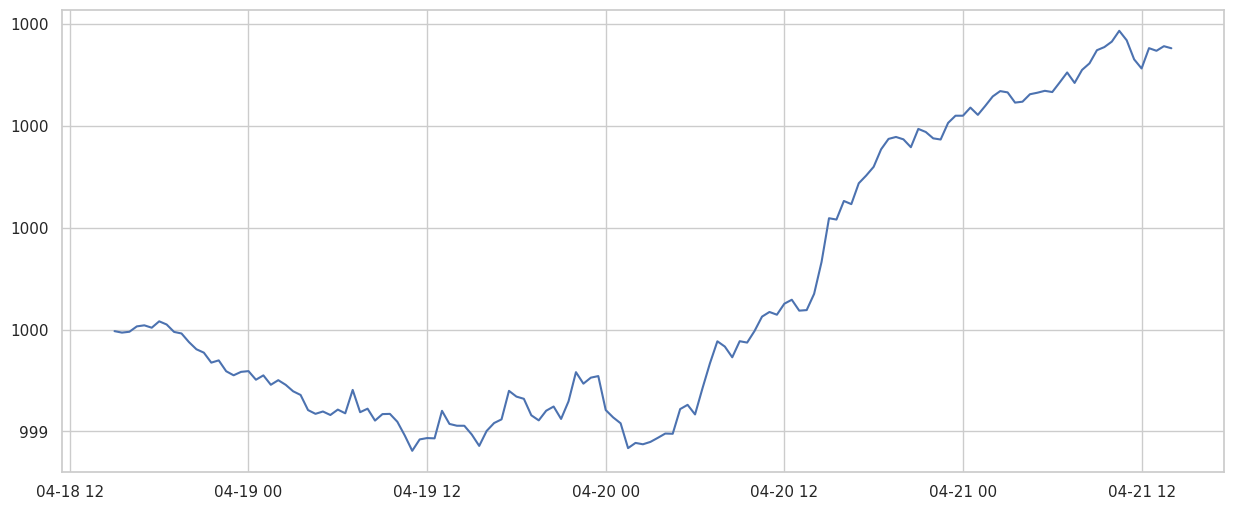

In [42]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['trade_net_taker_equity_curve'], label="Data")
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))
plt.show()

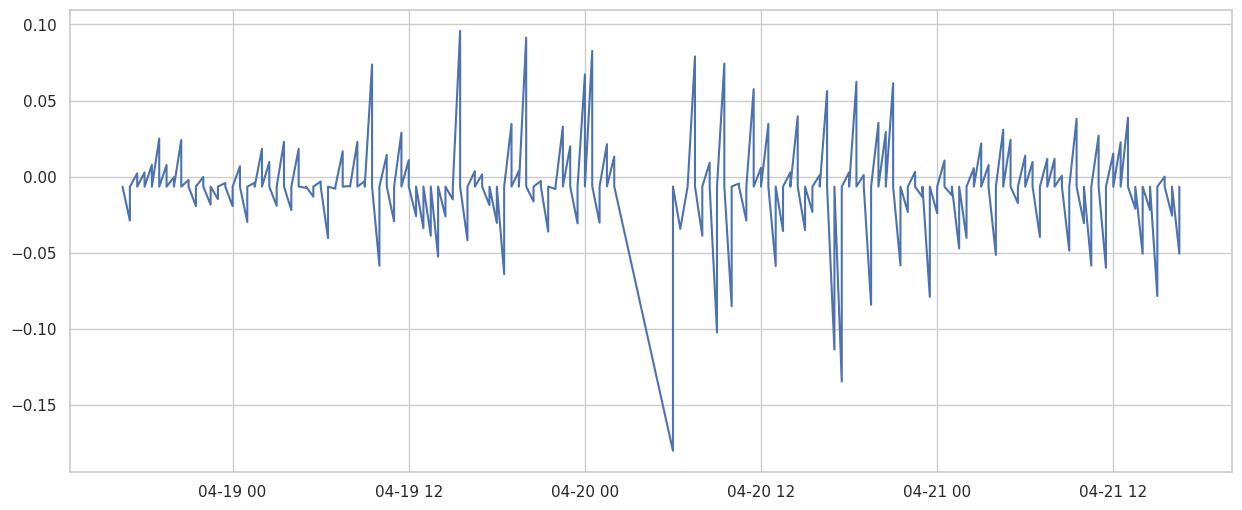

In [54]:
df_actual = df_actual[df_actual['time'] >= '4/18/2026 - 16:30:01']
plt.figure(figsize=(15, 6))
plt.plot(pd.to_datetime(df_actual['time']), df_actual['closedPnl'], label="Data")

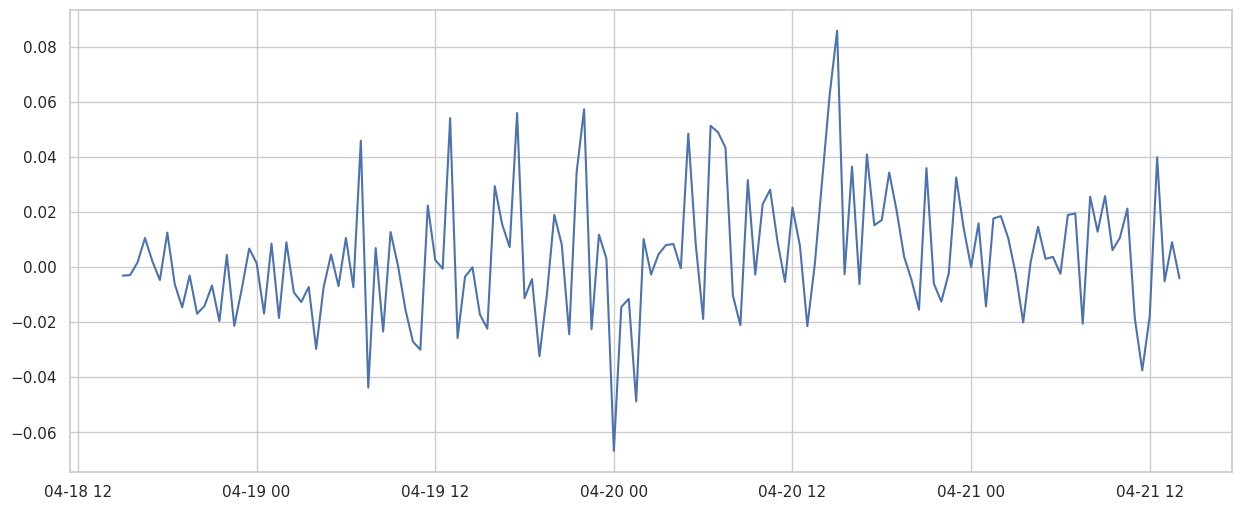

In [58]:
plt.figure(figsize=(15, 6))
plt.plot(pd.to_datetime(df.index), df['trade_net_taker_pnl'], label="Data")

In [45]:
df_actual = pd.read_csv("trade_history.csv")

In [55]:
df_actual.head()

,time,coin,dir,px,sz,ntl,fee,closedPnl
7,4/18/2026 - 16:30:01,BTC,Open Short,76103.0,0.0002,15.2206,0.006575,-0.006575
8,4/18/2026 - 17:00:02,BTC,Close Short,76214.0,0.0002,15.2428,0.006584,-0.028784
9,4/18/2026 - 17:00:04,BTC,Open Short,76213.0,0.0002,15.2426,0.006584,-0.006584
10,4/18/2026 - 17:30:02,BTC,Close Short,76169.0,0.0002,15.2338,0.006581,0.002219
11,4/18/2026 - 17:30:04,BTC,Open Short,76168.0,0.0002,15.2336,0.006580,-0.006580


In [ ]:
df[df['won']==True]
df.shape

(143, 31)

In [57]:
df.head(50)

,Open,High,Low,Close,Volume,sma_20,sma_50,rsi_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,pred,won,signal,trade_log_return_predict,equity_curve_predict,fees,trade_log_return_predict_fees,equity_curve_predict_fees,entry_trace,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,trade_net_taker_pnl,trade_net_taker_equity_curve
Open time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-18 15:00:00,76285.21,76397.74,76161.26,76242.85,47.07757,76526.0195,77046.7400,37.529818,-227.100578,-12.399931,-214.700647,-0.000555,0.001432,0.000346,0.000319,-0.002714,True,-1.0,0.000555,0.000555,-0.000864,-0.000309,-0.000309,10.0,10.005556,0.0002,-0.0002,0.005556,0.008642,-0.003086,999.996914
2026-04-18 15:30:00,76240.46,76270.55,76037.00,76199.10,54.10321,76477.4725,77012.1302,36.256124,-219.669423,-3.975020,-215.694402,-0.000574,-0.000555,0.001432,0.000346,-0.002821,True,-1.0,0.000574,0.001129,-0.000864,-0.000290,-0.000599,10.0,10.005742,0.0002,-0.0002,0.005742,0.008642,-0.002901,999.994013
2026-04-18 16:00:00,76199.09,76257.23,75727.98,76120.39,167.36605,76427.3200,76978.6370,34.019208,-217.622798,-1.542716,-216.080082,-0.001033,-0.000574,-0.000555,0.001432,-0.003232,True,-1.0,0.001033,0.002163,-0.000864,0.000169,-0.000430,10.0,10.010340,0.0002,-0.0002,0.010340,0.008644,0.001696,999.995708
2026-04-18 16:30:00,76120.40,76164.33,75897.46,75974.41,60.86826,76367.8710,76941.3878,30.286949,-225.184413,-7.283465,-217.900948,-0.001920,-0.001033,-0.000574,-0.000555,-0.003801,True,-1.0,0.001920,0.004083,-0.000864,0.001055,0.000625,10.0,10.019214,0.0002,-0.0002,0.019214,0.008648,0.010566,1000.006274
2026-04-18 17:00:00,75974.41,75995.16,75816.75,75893.21,99.10279,76306.3960,76895.0012,28.419247,-235.020044,-13.695277,-221.324767,-0.001069,-0.001920,-0.001033,-0.000574,-0.003928,True,-1.0,0.001069,0.005152,-0.000864,0.000205,0.000830,10.0,10.010699,0.0002,-0.0002,0.010699,0.008645,0.002055,1000.008329
2026-04-18 17:30:00,75893.22,75934.80,75863.12,75863.12,25.19072,76247.9300,76854.1158,27.736661,-242.448074,-16.898645,-225.549428,-0.000397,-0.001069,-0.001920,-0.001033,-0.004049,True,-1.0,0.000397,0.005548,-0.000864,-0.000468,0.000362,10.0,10.003966,0.0002,-0.0002,0.003966,0.008642,-0.004675,1000.003654
2026-04-18 18:00:00,75863.12,75883.44,75637.41,75702.77,68.40933,76196.8840,76822.4450,24.376587,-258.296267,-26.197471,-232.098796,-0.002116,-0.000397,-0.001069,-0.001920,-0.005109,True,-1.0,0.002116,0.007664,-0.000864,0.001252,0.001614,10.0,10.021182,0.0002,-0.0002,0.021182,0.008649,0.012532,1000.016186
2026-04-18 18:30:00,75702.77,75770.26,75477.53,75684.36,108.41893,76142.8335,76784.8434,24.016854,-269.238000,-29.711363,-239.526637,-0.000243,-0.002116,-0.000397,-0.001069,-0.004945,True,-1.0,0.000243,0.007908,-0.000864,-0.000621,0.000993,10.0,10.002432,0.0002,-0.0002,0.002432,0.008641,-0.006209,1000.009977
2026-04-18 19:00:00,75684.36,75834.98,75657.46,75729.44,30.40405,76098.6810,76754.6972,26.863014,-271.146217,-25.295664,-245.850553,0.000595,-0.000243,-0.002116,-0.000397,-0.004388,False,-1.0,-0.000595,0.007312,-0.000864,-0.001460,-0.000467,10.0,9.994047,0.0002,-0.0002,-0.005953,0.008637,-0.014590,999.995387
